In [2]:
import numpy as np
import matplotlib.pyplot as plt

AND: epochs = 6 w = [1.  0.5] b = -1.0
AND: mistakes per epoch = [1, 3, 3, 2, 1, 0]
AND: final predictions  = [0 0 0 1]
XOR: epochs = 20 w = [-0.5  0. ] b = 0.5
XOR: mistakes per epoch = [2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
XOR: final predictions  = [1 1 0 0]


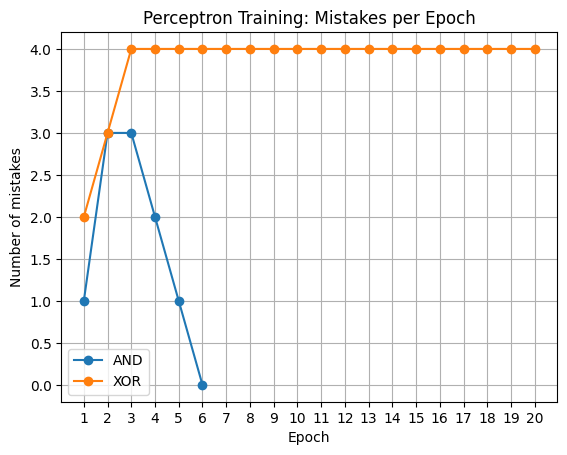


Wrong AND predictions:

Wrong XOR predictions:
X = [0. 0.] expecred = 0 predicted = 1
X = [1. 0.] expecred = 1 predicted = 0
Task 1 OK


In [9]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])

y_and = np.array([0, 0, 0, 1])
y_xor = np.array([0, 1, 1, 0])


def predict(X, w, b):
       scores = X @ w + b
       return (scores > 0).astype(int)


def train_perceptron(X, y, eta=0.5, max_epochs=20):

    w = np.zeros(2)
    b = 0.0

    mistakes_per_epoch = []

    for epoch in range(max_epochs):

        mistakes = 0

        for i in range(len(X)):

            y_hat = predict(X[i:i+1], w, b)[0]
            if y_hat != y[i]:
                mistakes += 1
            error = y[i] - y_hat
            w = w + eta * error * X[i]
            b = b + eta * error
            

        mistakes_per_epoch.append(mistakes)

        if mistakes == 0:
             break

    return w, b, mistakes_per_epoch


w_and, b_and, hist_and = train_perceptron(X, y_and)
w_xor, b_xor, hist_xor = train_perceptron(X, y_xor)

print("AND: epochs =", len(hist_and), "w =", w_and, "b =", b_and)
print("AND: mistakes per epoch =", hist_and)
print("AND: final predictions  =", predict(X, w_and, b_and))

print("XOR: epochs =", len(hist_xor), "w =", w_xor, "b =", b_xor)
print("XOR: mistakes per epoch =", hist_xor)
print("XOR: final predictions  =", predict(X, w_xor, b_xor))


plt.plot(range(1, len(hist_and) + 1), hist_and, marker="o", label="AND")
plt.plot(range(1, len(hist_xor) + 1), hist_xor, marker="o", label="XOR")

plt.xlabel("Epoch")
plt.ylabel("Number of mistakes")
plt.title("Perceptron Training: Mistakes per Epoch")
plt.xticks(range(1, max(len(hist_and), len(hist_xor)) + 1))
plt.legend()
plt.grid()

plt.show()


pred_and = predict(X, w_and, b_and)
pred_xor = predict(X, w_xor, b_xor)

print("\nWrong AND predictions:")
for i in range(len(X)):
    if pred_and[i] != y_and[i]:
        print("X =", X[i], "expected =", y_and[i], "predicted =", pred_and[i])

print("\nWrong XOR predictions:")
for i in range(len(X)):
     if pred_xor[i] != y_xor[i]:
          print("X =", X[i], "expecred =", y_xor[i], "predicted =", pred_xor[i])

assert np.all(predict(X, w_and, b_and) == y_and)

print("Task 1 OK")